In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../Mamoth Modules")
sys.path.insert(0, "../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
shape_file = pd.read_csv(f'data/{NUTS0}_{NUTS2}_Spatiotemproal_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'data/{NUTS0}_{NUTS2}_Epidemiological_Timeline_2010-2021.csv', encoding=enc)

In [4]:
shape_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,idy,idx,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-01,2010,1,2009-12-07,40.318636,24.050146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.318636,24.050146,14488.0,14284.0,118,538,40.318636,24.050146,14240.714286,14017.875000,14168.363636,13858.000000,14387.000000,13984.437500,14537.476190,14146.937500,25.7,90.5,0.6
1,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-16,2010,1,2009-12-07,40.318636,24.050146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.318636,24.050146,14232.0,14049.0,118,538,40.318636,24.050146,14240.714286,14017.875000,14168.363636,13858.000000,14387.000000,13984.437500,14537.476190,14146.937500,4.7,6.2,6.8
2,αθως,κεντρικης μακεδονιας,24.05105,40.35544,2010-01-01,2010,1,2009-12-07,40.354568,24.050146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.354568,24.050146,14469.0,14289.0,126,538,40.354568,24.050146,14215.714286,14068.125000,14142.181818,13923.888889,14352.250000,14009.000000,14491.700000,14138.562500,25.7,90.5,0.6
3,αθως,κεντρικης μακεδονιας,24.05105,40.35544,2010-01-16,2010,1,2009-12-07,40.354568,24.050146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.354568,24.050146,14268.0,14085.0,126,538,40.354568,24.050146,14215.714286,14068.125000,14142.181818,13923.888889,14352.250000,14009.000000,14491.700000,14138.562500,4.7,6.2,6.8
4,αθως,κεντρικης μακεδονιας,24.09803,40.31951,2010-01-01,2010,1,2009-12-07,40.318636,24.099553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.318636,24.099553,14455.0,14099.0,118,549,40.318636,24.099553,14249.428571,14069.833333,14104.090909,13837.888889,14355.384615,13972.642857,14578.619048,14102.333333,25.7,90.5,0.6


In [5]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11


In [6]:
shape_file.rename(columns={"region": "nuts2"}, inplace=True)

In [7]:
process_greek(shape_file, 'lau1')
process_greek(shape_file, 'nuts2')

In [8]:
shape_file = shape_file.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
shape_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon', 'idy','idx','monthly_lst_lat','monthly_lst_lon'], inplace = True)

In [10]:
shape_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14488.0,14284.0,14240.714286,14017.875000,14168.363636,13858.000000,14387.000000,13984.437500,14537.476190,14146.937500,25.7,90.5,0.6
1,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14232.0,14049.0,14240.714286,14017.875000,14168.363636,13858.000000,14387.000000,13984.437500,14537.476190,14146.937500,4.7,6.2,6.8
2,αθως,κεντρικης μακεδονιας,24.05105,40.35544,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14469.0,14289.0,14215.714286,14068.125000,14142.181818,13923.888889,14352.250000,14009.000000,14491.700000,14138.562500,25.7,90.5,0.6
3,αθως,κεντρικης μακεδονιας,24.05105,40.35544,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14268.0,14085.0,14215.714286,14068.125000,14142.181818,13923.888889,14352.250000,14009.000000,14491.700000,14138.562500,4.7,6.2,6.8
4,αθως,κεντρικης μακεδονιας,24.09803,40.31951,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14455.0,14099.0,14249.428571,14069.833333,14104.090909,13837.888889,14355.384615,13972.642857,14578.619048,14102.333333,25.7,90.5,0.6


In [11]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11


In [12]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_shapefile = shape_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_shapefile:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


['ηρωικης πολης ναουσας']

Length: 1


In [13]:
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολης ναουσας','ναουσας'))

In [14]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_shapefile = shape_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_shapefile:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [15]:
merged = shape_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [16]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case
0,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14488.0,14284.0,14240.714286,14017.875000,14168.363636,13858.000000,14387.000000,13984.437500,14537.476190,14146.937500,25.7,90.5,0.60,NaN
1,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14232.0,14049.0,14240.714286,14017.875000,14168.363636,13858.000000,14387.000000,13984.437500,14537.476190,14146.937500,4.7,6.2,6.80,NaN
2,αθως,κεντρικης μακεδονιας,24.05105,40.35544,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14469.0,14289.0,14215.714286,14068.125000,14142.181818,13923.888889,14352.250000,14009.000000,14491.700000,14138.562500,25.7,90.5,0.60,NaN
3,αθως,κεντρικης μακεδονιας,24.05105,40.35544,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14268.0,14085.0,14215.714286,14068.125000,14142.181818,13923.888889,14352.250000,14009.000000,14491.700000,14138.562500,4.7,6.2,6.80,NaN
4,αθως,κεντρικης μακεδονιας,24.09803,40.31951,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14455.0,14099.0,14249.428571,14069.833333,14104.090909,13837.888889,14355.384615,13972.642857,14578.619048,14102.333333,25.7,90.5,0.60,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52987,καλαμαριας,κεντρικης μακεδονιας,22.95724,40.57876,2021-12-16,2021,12,0.172220,0.020770,-0.164460,-0.020770,0.176418,0.038989,-0.152832,-0.038989,0.088001,0.037532,0.078183,0.037532,NaN,NaN,14129.333333,13709.444444,14213.533333,13980.263158,14418.333333,13990.705882,14742.687500,14134.357143,NaN,NaN,744.45,NaN
52988,κορδελιου ευοσμου,κεντρικης μακεδονιας,22.90326,40.67609,2021-12-01,2021,12,0.264806,0.069353,-0.219160,-0.069353,0.265607,0.066869,-0.225792,-0.066869,0.100216,0.033313,0.079533,0.033313,NaN,NaN,14178.083333,13673.100000,14392.384615,13947.250000,14636.769231,13941.000000,14965.928571,14095.090909,13.7,32.4,757.85,NaN
52989,κορδελιου ευοσμου,κεντρικης μακεδονιας,22.90326,40.67609,2021-12-16,2021,12,0.264806,0.069353,-0.219160,-0.069353,0.265607,0.066869,-0.225792,-0.066869,0.100216,0.033313,0.079533,0.033313,NaN,NaN,14178.083333,13673.100000,14392.384615,13947.250000,14636.769231,13941.000000,14965.928571,14095.090909,NaN,NaN,757.85,NaN
52990,νεαπολης συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-01,2021,12,0.471588,0.219807,-0.341895,-0.219807,0.432801,0.194751,-0.303206,-0.194751,0.029589,0.053035,0.040277,0.053035,NaN,NaN,14065.538462,13698.800000,14360.500000,13944.500000,14485.294118,13952.187500,14762.937500,14079.785714,13.7,32.4,757.85,NaN


In [17]:
merged = fillna(merged,{'case': 0, 'acc_rainfall_1week':0, 'acc_rainfall_2week':0, 'acc_rainfall_jan':0})

In [18]:
merged['case'].value_counts()

0.0     51476
1.0       901
2.0       306
3.0       118
4.0        82
        ...  
8.0        10
18.0        5
12.0        5
9.0         5
11.0        4
Name: case, Length: 13, dtype: int64

In [19]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [20]:
dataset = grouped.mean()

In [21]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case
0,2010-01-01,αθως,κεντρικης μακεδονιας,24.127400,40.288067,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14434.000000,14145.250000,14189.164286,13999.125000,14101.659091,13848.087302,14311.681381,13959.395089,14489.242927,14085.791667,34.075000,97.500000,0.575000,0.0
1,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.413142,40.631208,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14275.500000,14010.000000,14002.885417,13877.808036,14194.027778,13755.375874,14614.979487,13877.330882,15058.503571,14122.943298,14.800000,40.250000,0.000000,0.0
2,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,22.074666,40.991725,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14136.454545,13917.363636,13823.172078,13757.577994,13857.414899,13698.833786,14212.516070,13759.738566,14614.420911,13951.703457,20.218182,39.590909,0.045455,0.0
3,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.000000,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,15.000000,39.900000,0.000000,0.0
4,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.970670,40.919595,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.000000,14066.500000,14064.650000,13855.185714,14167.965774,13766.781818,14419.962912,13835.285256,14693.641026,14080.251768,20.225000,29.825000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11227,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.893716,40.070738,2021.0,12.0,0.543053,0.209417,-0.421479,-0.209417,0.546873,0.239082,-0.413448,-0.239082,0.043793,0.056892,0.055196,0.056892,NaN,NaN,14131.435673,13826.602778,14303.194872,14011.907418,14370.690392,13938.017179,14614.959055,14054.843317,0.000000,0.000000,1197.790000,0.0
11228,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.388056,41.308585,2021.0,12.0,0.166584,0.158476,-0.072889,-0.158476,0.142908,0.143278,-0.065802,-0.143278,0.036802,0.049390,0.048440,0.049390,NaN,NaN,13897.215289,13531.668956,14215.206734,13855.539685,14435.830992,13752.843721,14656.776777,13918.508000,0.000000,0.000000,800.000000,0.0
11229,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2021.0,12.0,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,0.000000,0.000000,495.750000,0.0
11230,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2021.0,12.0,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.240922,0.030417,0.059156,0.056067,0.041252,0.056067,NaN,NaN,14117.840476,13553.251852,14456.092308,13851.944444,14692.609280,13852.974401,14831.047863,14012.847619,0.000000,0.000000,667.100000,0.0


In [22]:
dataset = dataset.astype({'case': 'int'})

In [23]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [24]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [25]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [26]:
with open(f'data/{NUTS0}_WNV_{NUTS2}_LAU1_mapping.json', 'w', encoding=enc) as file:
     json.dump(lau1_map,file,sort_keys=True, indent=4, ensure_ascii=False)

In [27]:
dataset["lau1_id"] = dataset["lau1"].map(lau1_map)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [28]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αθως,κεντρικης μακεδονιας,24.12740,40.28807,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14434.000000,14145.250000,14189.164286,13999.125000,14101.659091,13848.087302,14311.681381,13959.395089,14489.242927,14085.791667,34.075000,97.500000,0.575000,0,1,53,46.96020,28,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
1,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.41314,40.63121,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14275.500000,14010.000000,14002.885417,13877.808036,14194.027778,13755.375874,14614.979487,13877.330882,15058.503571,14122.943298,14.800000,40.250000,0.000000,0,1,53,46.40306,7,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
2,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,22.07467,40.99173,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14136.454545,13917.363636,13823.172078,13757.577994,13857.414899,13698.833786,14212.516070,13759.738566,14614.420911,13951.703457,20.218182,39.590909,0.045455,0,1,53,46.55763,13,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
3,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.000000,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,15.000000,39.900000,0.000000,0,1,53,46.65786,17,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
4,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.97067,40.91960,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.000000,14066.500000,14064.650000,13855.185714,14167.965774,13766.781818,14419.962912,13835.285256,14693.641026,14080.251768,20.225000,29.825000,0.000000,0,1,53,47.42369,35,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11227,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.89372,40.07074,2021,12,0.543053,0.209417,-0.421479,-0.209417,0.546873,0.239082,-0.413448,-0.239082,0.043793,0.056892,0.055196,0.056892,NaN,NaN,14131.435673,13826.602778,14303.194872,14011.907418,14370.690392,13938.017179,14614.959055,14054.843317,0.000000,0.000000,1197.790000,0,16,50,46.65377,16,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
11228,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.30859,2021,12,0.166584,0.158476,-0.072889,-0.158476,0.142908,0.143278,-0.065802,-0.143278,0.036802,0.049390,0.048440,0.049390,NaN,NaN,13897.215289,13531.668956,14215.206734,13855.539685,14435.830992,13752.843721,14656.776777,13918.508000,0.000000,0.000000,800.000000,0,16,50,47.47000,37,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
11229,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2021,12,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,0.000000,0.000000,495.750000,0,16,50,46.44339,8,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
11230,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2021,12,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.240922,0.030417,0.059156,0.056067,0.041252,0.056067,NaN,NaN,14117.840476,13553.251852,14456.092308,13851.944444,14692.609280,13852.974401,14831.047863,14012.847619,0.000000,0.000000,667.100000,0,16,50,46.66036,19,-0.101168,

<AxesSubplot:>

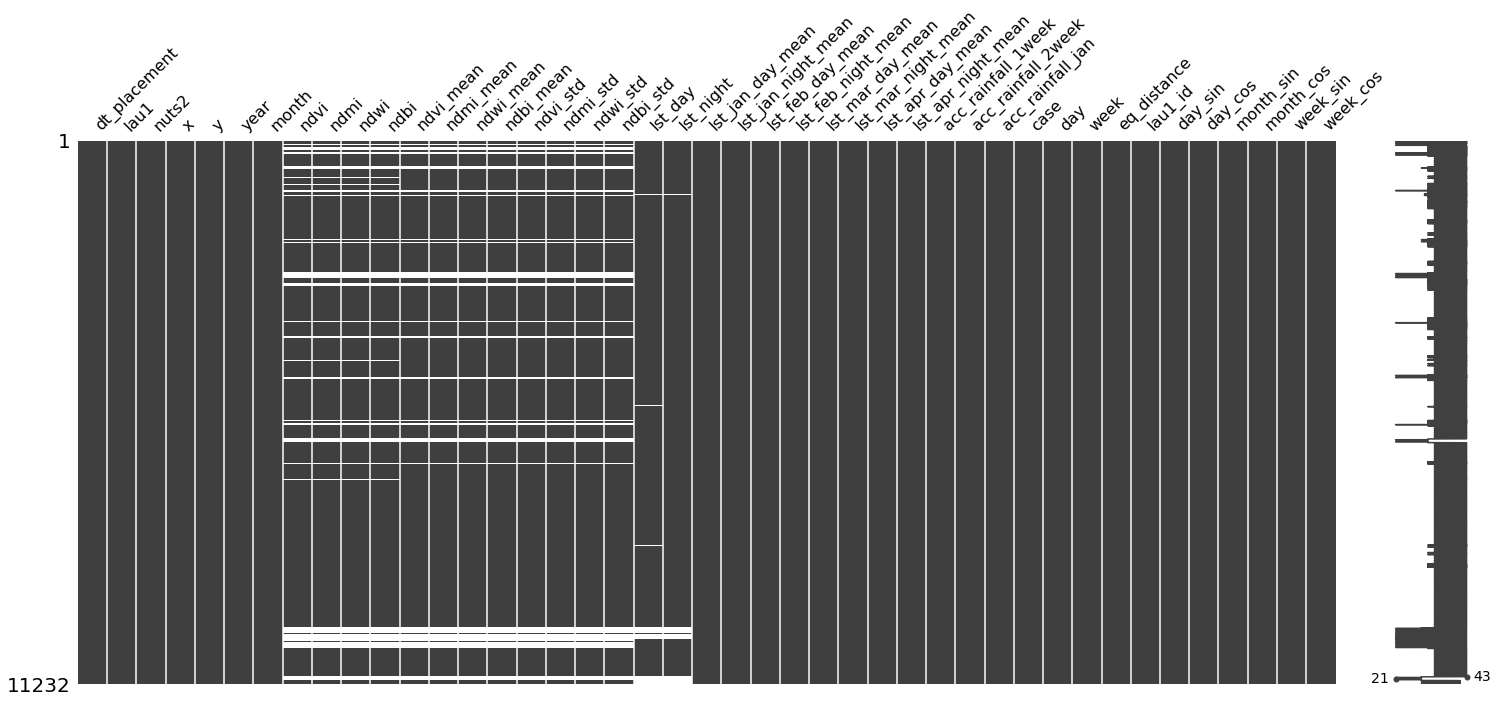

In [29]:
missingno.matrix(dataset)

In [30]:
df_demographics = pd.read_csv(f'data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [31]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [32]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [33]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [34]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αλεξανδρειας,478.8,86.8,38293.0
1,αλμωπιας,985.8,28.0,24924.0
2,αμπελοκηπων μενεμενης,9.8,5319.1,49674.0
3,αμφιπολης,411.8,22.3,7169.0
4,αριστοτελη,747.0,24.5,16994.0
...,...,...,...,...
33,σιθωνιας,516.8,24.0,11631.0
34,σιντικης,1103.4,20.1,18532.0
35,σκυδρας,239.5,84.3,18080.0
36,χαλκηδονος,391.5,86.0,29951.0


In [35]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['αθως', 'ναουσας']

Length: 2


In [36]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [37]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['αθως']

Length: 1


In [38]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

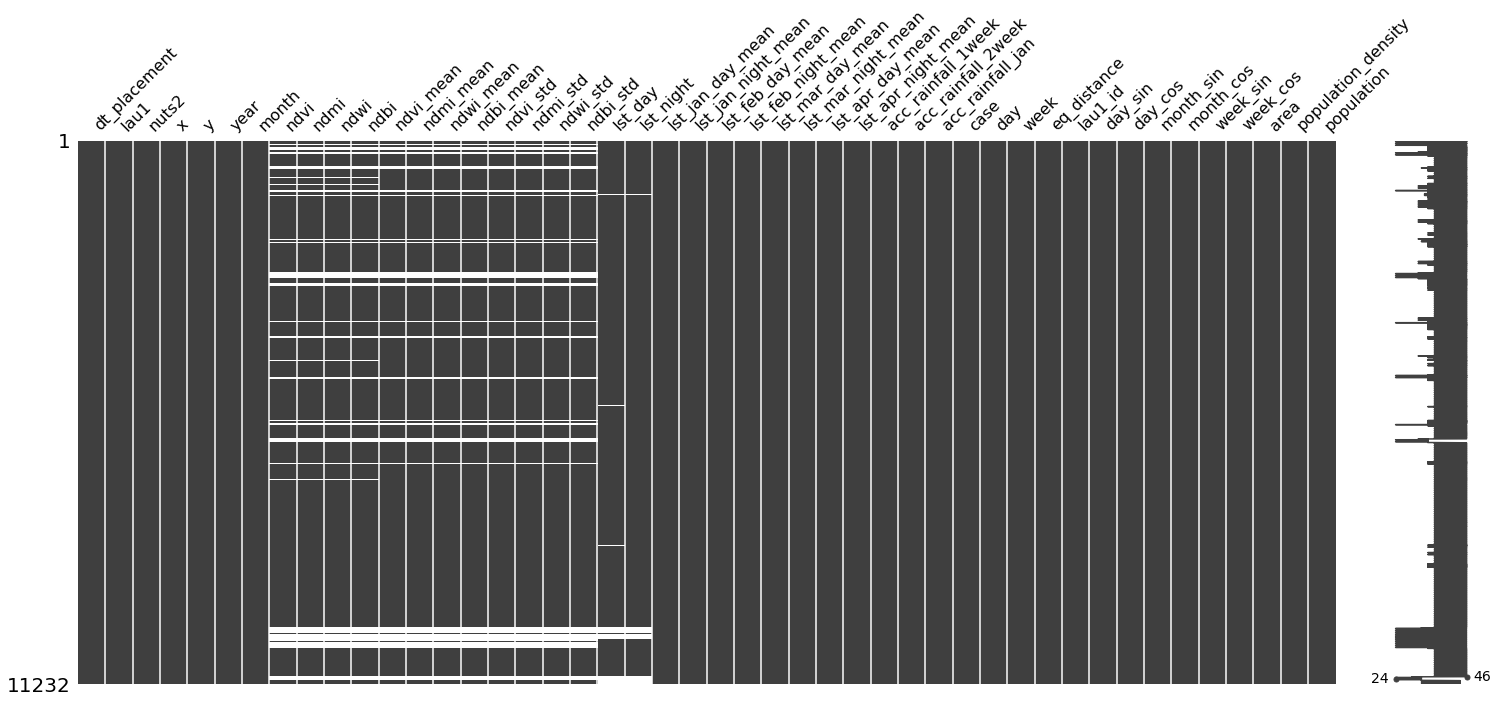

In [39]:
missingno.matrix(dataset)

In [40]:
missing = describe_dataframe(dataset)

In [41]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2010-01-01,αθως,κεντρικης μακεδονιας,24.12740,40.28807,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14434.000000,14145.250000,14189.164286,13999.125000,14101.659091,13848.087302,14311.681381,13959.395089,14489.242927,14085.791667,34.075000,97.500000,0.575000,0,1,53,46.96020,28,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,NaN,NaN,NaN
1,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.41314,40.63121,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14275.500000,14010.000000,14002.885417,13877.808036,14194.027778,13755.375874,14614.979487,13877.330882,15058.503571,14122.943298,14.800000,40.250000,0.000000,0,1,53,46.40306,7,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,478.8,86.8,38293.0
2,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,22.07467,40.99173,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14136.454545,13917.363636,13823.172078,13757.577994,13857.414899,13698.833786,14212.516070,13759.738566,14614.420911,13951.703457,20.218182,39.590909,0.045455,0,1,53,46.55763,13,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,985.8,28.0,24924.0
3,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.000000,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,15.000000,39.900000,0.000000,0,1,53,46.65786,17,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,9.8,5319.1,49674.0
4,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.97067,40.91960,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.000000,14066.500000,14064.650000,13855.185714,14167.965774,13766.781818,14419.962912,13835.285256,14693.641026,14080.251768,20.225000,29.825000,0.000000,0,1,53,47.42369,35,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,411.8,22.3,7169.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11227,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.89372,40.07074,2021,12,0.543053,0.209417,-0.421479,-0.209417,0.546873,0.239082,-0.413448,-0.239082,0.043793,0.056892,0.055196,0.056892,NaN,NaN,14131.435673,13826.602778,14303.194872,14011.907418,14370.690392,13938.017179,14614.959055,14054.843317,0.000000,0.000000,1197.790000,0,16,50,46.65377,16,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,516.8,24.0,11631.0
11228,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.30859,2021,12,0.166584,0.158476,-0.072889,-0.158476,0.142908,0.143278,-0.065802,-0.143278,0.036802,0.049390,0.048440,0.049390,NaN,NaN,13897.215289,13531.668956,14215.206734,13855.539685,14435.830992,13752.843721,14656.776777,13918.508000,0.000000,0.000000,800.000000,0,16,50,47.47000,37,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,1103.4,20.1,18532.0
11229,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2021,12,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,0.000000,0.000000,495.750000,0,16,50,46.44339,8,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,239.5,84.3,18080.0
11230,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2021,12,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.240922,0.030417,0.059156,0.0560

In [42]:
mosquito_data = read_data(f'data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [43]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [44]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [45]:
mosq_columns = mosquito_data_nuts2.columns

In [46]:
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [47]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


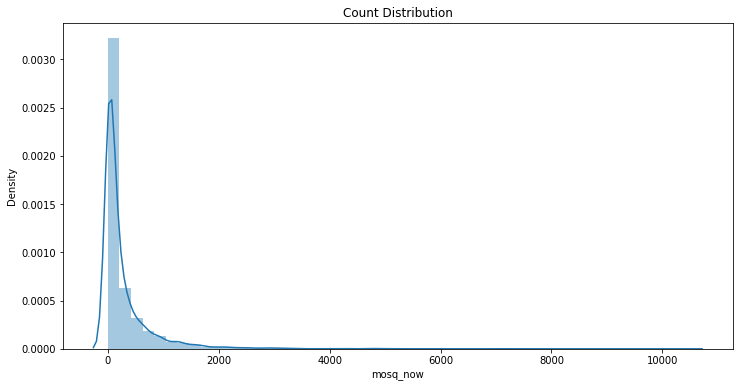

In [48]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [49]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_13664/187358562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


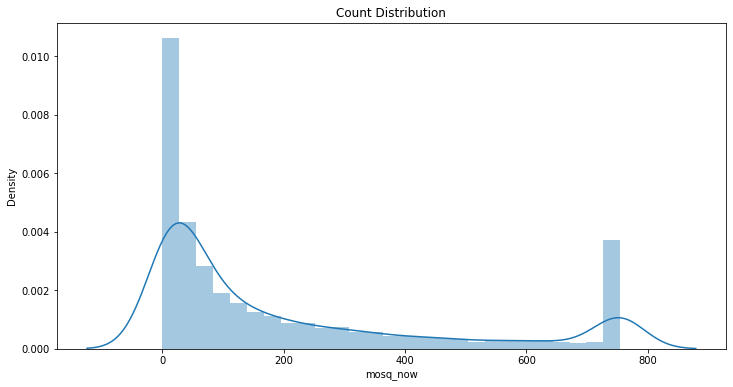

In [50]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

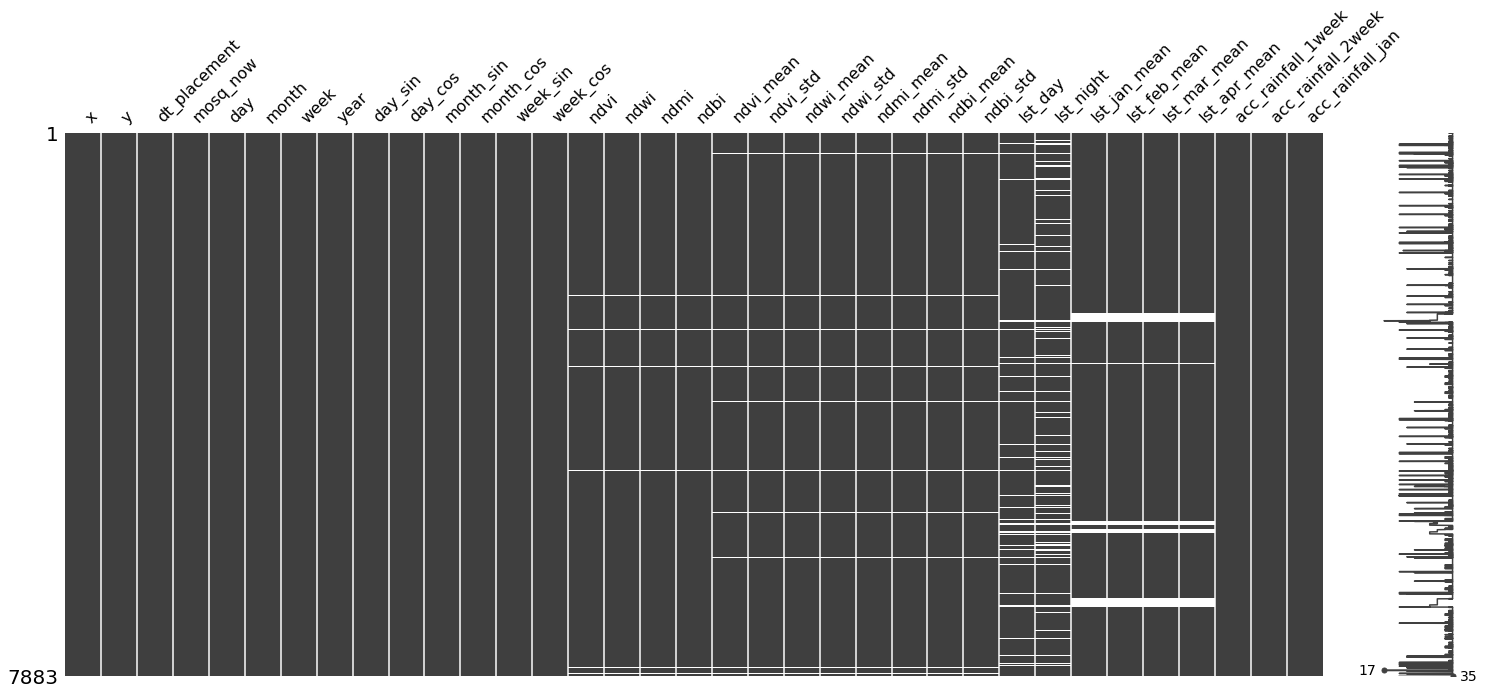

In [51]:
missingno.matrix(mosquito_data_nuts2)

In [52]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [53]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

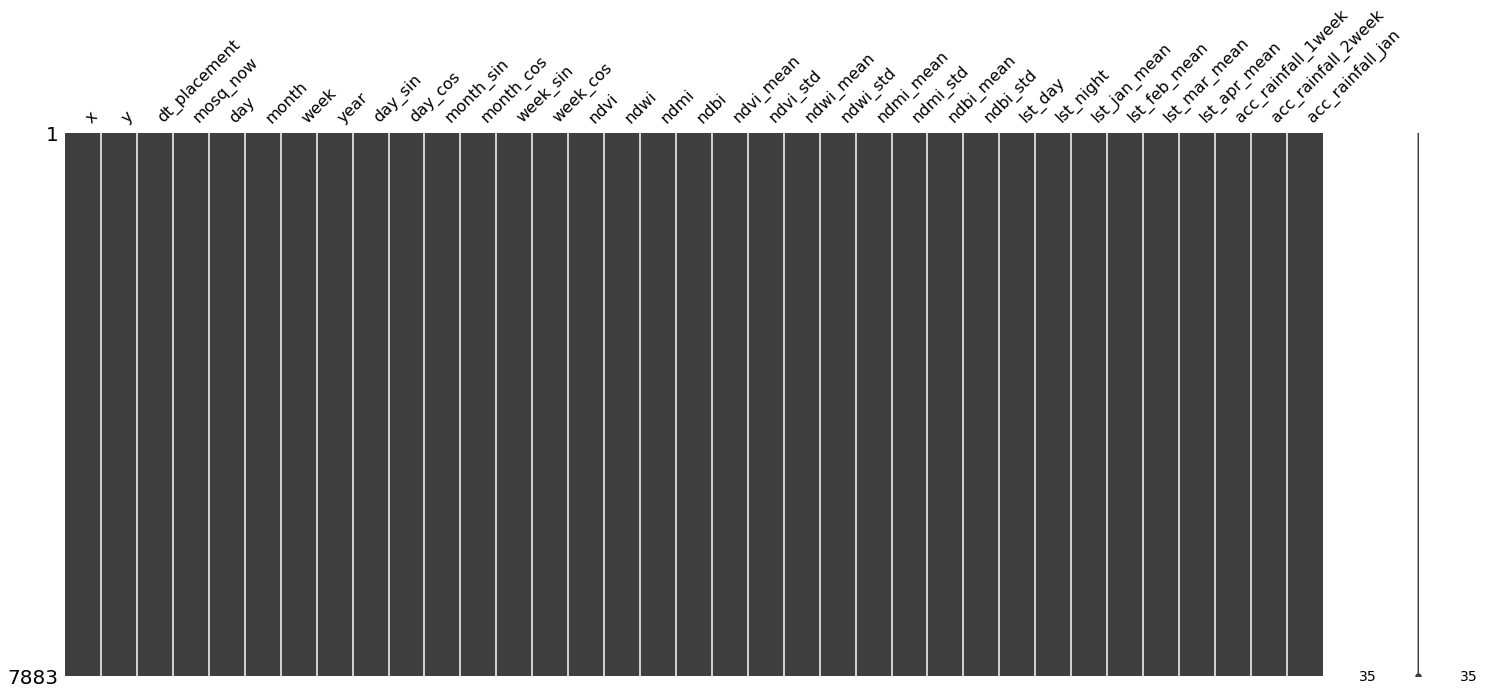

In [54]:
missingno.matrix(mosquito_data_nuts2)

In [55]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [56]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [57]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 19.57088 | Val Loss: 25.08696 | Train Acc: 2.654| Val Acc: 2.003
Epoch 002: | Train Loss: 18.84175 | Val Loss: 24.93425 | Train Acc: 2.284| Val Acc: 2.025
Epoch 003: | Train Loss: 18.48491 | Val Loss: 25.08603 | Train Acc: 2.209| Val Acc: 2.074
Epoch 004: | Train Loss: 18.02431 | Val Loss: 24.41425 | Train Acc: 2.138| Val Acc: 1.963
Epoch 005: | Train Loss: 17.77848 | Val Loss: 23.56762 | Train Acc: 2.101| Val Acc: 1.923
Epoch 006: | Train Loss: 17.43596 | Val Loss: 23.82993 | Train Acc: 2.058| Val Acc: 1.937
Epoch 007: | Train Loss: 17.29104 | Val Loss: 24.13965 | Train Acc: 2.050| Val Acc: 1.964
Epoch 008: | Train Loss: 17.06276 | Val Loss: 23.66927 | Train Acc: 2.023| Val Acc: 1.942
Epoch 009: | Train Loss: 16.91061 | Val Loss: 23.87656 | Train Acc: 2.026| Val Acc: 1.997
Epoch 010: | Train Loss: 16.86593 | Val Loss: 24.20744 | Train Acc: 2.014| Val Acc: 2.005
Epoch 011: | Train Loss: 16.78832 | Val Loss: 23.82412 | Train Acc: 2.021| Val Acc: 1.962
Epoch 012:

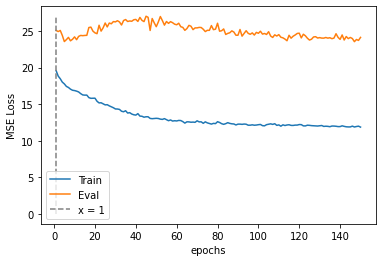

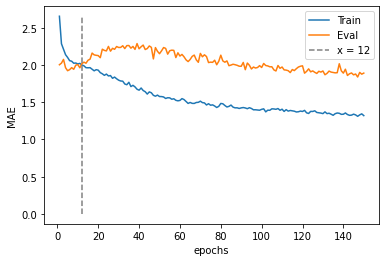

In [58]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [59]:
metrics(train, test, threshold=30)

MAE on train set:  128.81014233385807
min prediction: 1
max prediction: 988

MAE on test set:  146.43202077086906
Error ⩽ 30: 21.04 %
min prediction: 1
max prediction: 1155


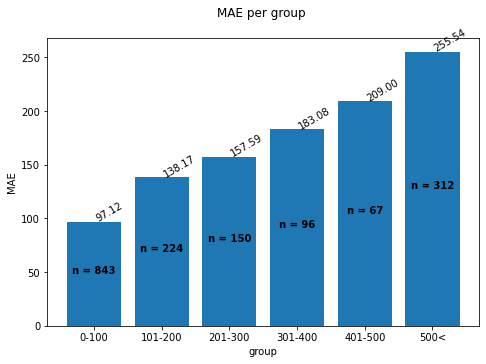

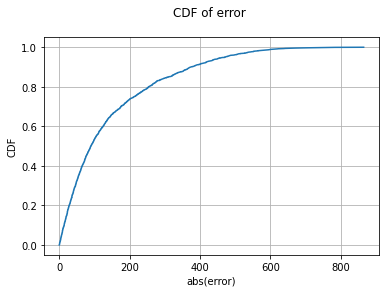

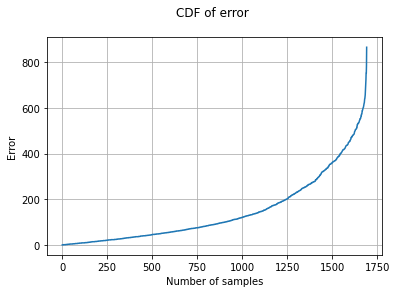

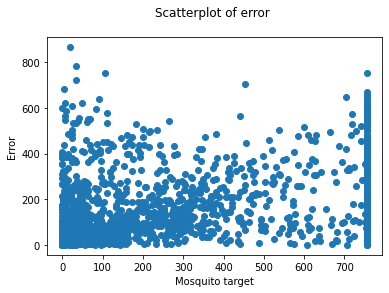

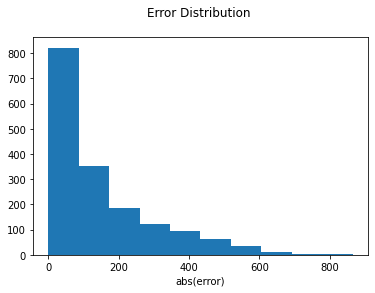

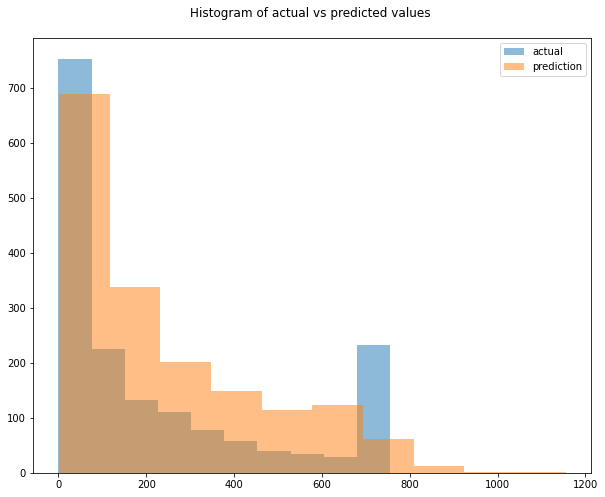

In [60]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.60188 | Val Loss: 0.19288 | Train Acc: 1.557| Val Acc: 0.633
Epoch 002: | Train Loss: 13.57144 | Val Loss: 0.70790 | Train Acc: 1.553| Val Acc: 0.633
Epoch 003: | Train Loss: 13.48699 | Val Loss: 1.17734 | Train Acc: 1.532| Val Acc: 0.633
Epoch 004: | Train Loss: 13.59708 | Val Loss: 1.45099 | Train Acc: 1.566| Val Acc: 1.633
Epoch 005: | Train Loss: 13.20619 | Val Loss: 1.06790 | Train Acc: 1.510| Val Acc: 0.633
Epoch 006: | Train Loss: 13.26846 | Val Loss: 1.21587 | Train Acc: 1.506| Val Acc: 0.633
Epoch 007: | Train Loss: 13.21420 | Val Loss: 1.88262 | Train Acc: 1.515| Val Acc: 1.633
Epoch 008: | Train Loss: 13.01447 | Val Loss: 1.50270 | Train Acc: 1.472| Val Acc: 1.633
Epoch 009: | Train Loss: 12.92387 | Val Loss: 1.13835 | Train Acc: 1.466| Val Acc: 0.633
Epoch 010: | Train Loss: 13.03413 | Val Loss: 2.05200 | Train Acc: 1.496| Val Acc: 1.633
Epoch 011: | Train Loss: 13.04708 | Val Loss: 3.82654 | Train Acc: 1.478| Val Acc: 1.633
Epoch 012: | Train Lo

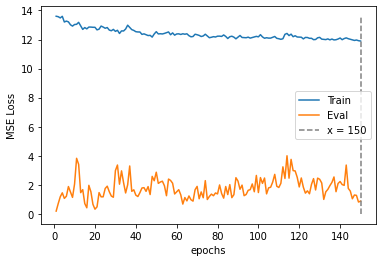

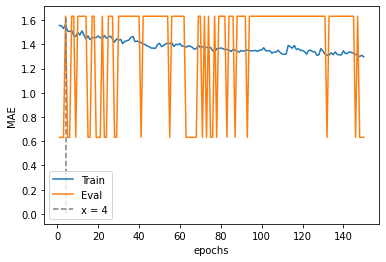

In [61]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [62]:
# mamoth_columns = ['x','y','dt_placement','day','month','week','year', 
#                   'day_sin','day_cos','month_sin','month_cos','week_sin','week_cos',
#                   'ndvi','ndmi','ndwi','ndbi', 'ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean', 
#                   'ndvi_std','ndmi_std','ndwi_std','ndbi_std',
#                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean', 
#                   'acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_jan', 'mosq_now' ]

In [63]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [64]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [65]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [66]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [67]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [68]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

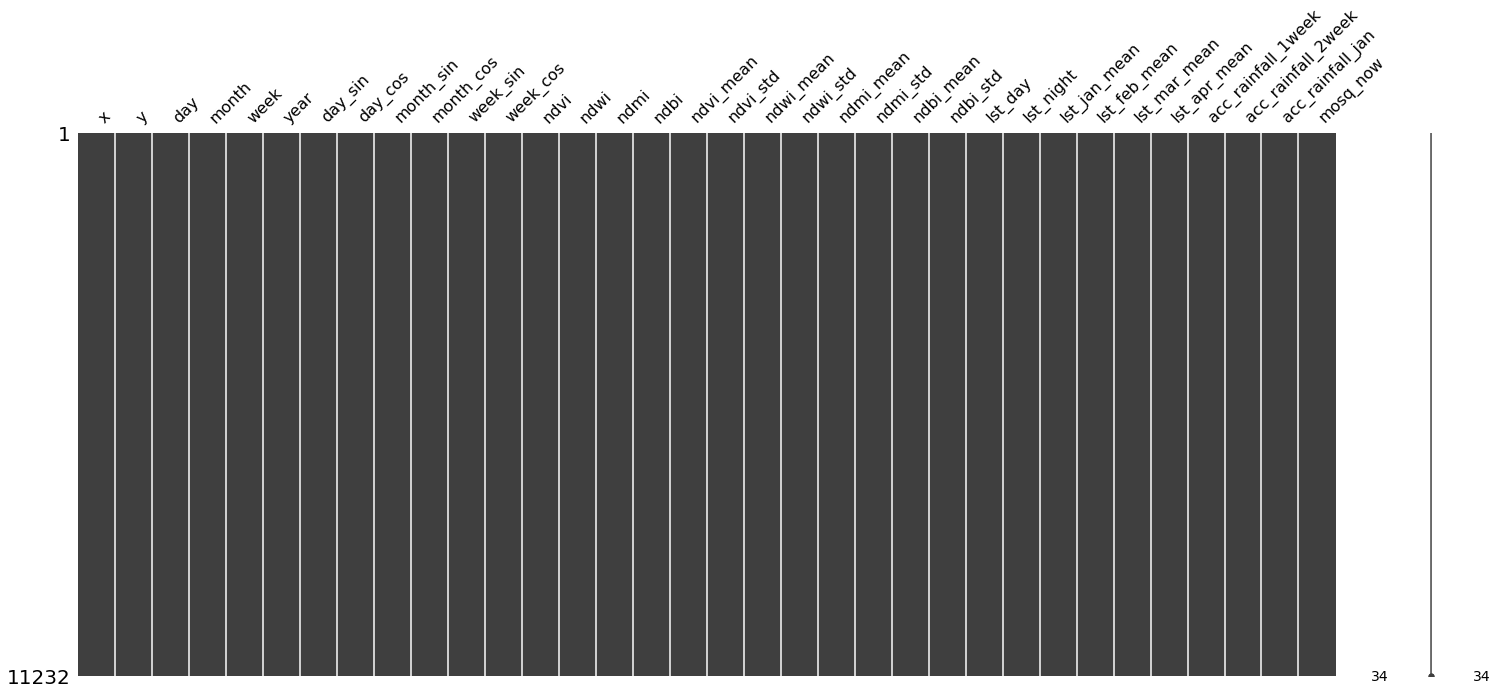

In [69]:
missingno.matrix(dataset_mamoth)

In [70]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [71]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [72]:
predictions = give_predictions(model, dataset_mamoth)

In [73]:
mosqutio_predictions['mosq_pred'] = predictions

In [74]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,24.12740,40.28807,2010-01-01,1
1,22.41314,40.63121,2010-01-01,1
2,22.07467,40.99173,2010-01-01,1
3,22.89198,40.65603,2010-01-01,3
4,23.97067,40.91960,2010-01-01,1
...,...,...,...,...
11227,23.89372,40.07074,2021-12-16,1
11228,23.38806,41.30859,2021-12-16,1
11229,22.14670,40.82294,2021-12-16,5
11230,22.72302,40.75357,2021-12-16,3


In [75]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x','y','dt_placement'])

In [76]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2010-01-01,αθως,κεντρικης μακεδονιας,24.12740,40.28807,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14434.000000,14145.250000,14189.164286,13999.125000,14101.659091,13848.087302,14311.681381,13959.395089,14489.242927,14085.791667,34.075000,97.500000,0.575000,0,1,53,46.96020,28,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,NaN,NaN,NaN,1
1,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.41314,40.63121,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14275.500000,14010.000000,14002.885417,13877.808036,14194.027778,13755.375874,14614.979487,13877.330882,15058.503571,14122.943298,14.800000,40.250000,0.000000,0,1,53,46.40306,7,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,478.8,86.8,38293.0,1
2,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,22.07467,40.99173,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14136.454545,13917.363636,13823.172078,13757.577994,13857.414899,13698.833786,14212.516070,13759.738566,14614.420911,13951.703457,20.218182,39.590909,0.045455,0,1,53,46.55763,13,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,985.8,28.0,24924.0,1
3,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.000000,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,15.000000,39.900000,0.000000,0,1,53,46.65786,17,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,9.8,5319.1,49674.0,3
4,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.97067,40.91960,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.000000,14066.500000,14064.650000,13855.185714,14167.965774,13766.781818,14419.962912,13835.285256,14693.641026,14080.251768,20.225000,29.825000,0.000000,0,1,53,47.42369,35,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,411.8,22.3,7169.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11227,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.89372,40.07074,2021,12,0.543053,0.209417,-0.421479,-0.209417,0.546873,0.239082,-0.413448,-0.239082,0.043793,0.056892,0.055196,0.056892,NaN,NaN,14131.435673,13826.602778,14303.194872,14011.907418,14370.690392,13938.017179,14614.959055,14054.843317,0.000000,0.000000,1197.790000,0,16,50,46.65377,16,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,516.8,24.0,11631.0,1
11228,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.30859,2021,12,0.166584,0.158476,-0.072889,-0.158476,0.142908,0.143278,-0.065802,-0.143278,0.036802,0.049390,0.048440,0.049390,NaN,NaN,13897.215289,13531.668956,14215.206734,13855.539685,14435.830992,13752.843721,14656.776777,13918.508000,0.000000,0.000000,800.000000,0,16,50,47.47000,37,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,1103.4,20.1,18532.0,1
11229,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2021,12,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,0.000000,0.000000,495.750000,0,16,50,46.44339,8,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,239.5,84.3,18080.0,5
11230,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2021,12,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.2

<AxesSubplot:>

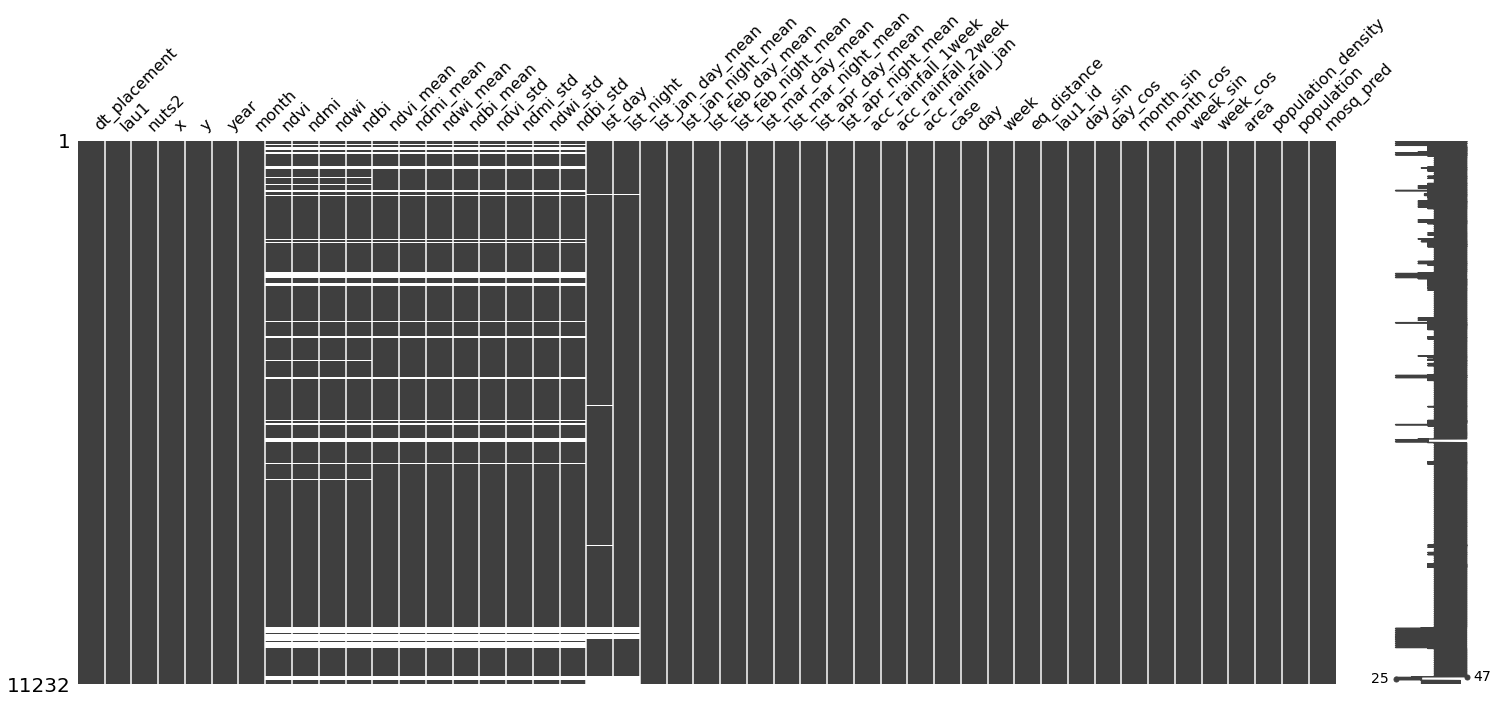

In [77]:
missingno.matrix(dataset)

In [78]:
dataset.reset_index(inplace=True, drop=True)

In [79]:
dataset = calculate_mosq_previous(dataset)

In [80]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

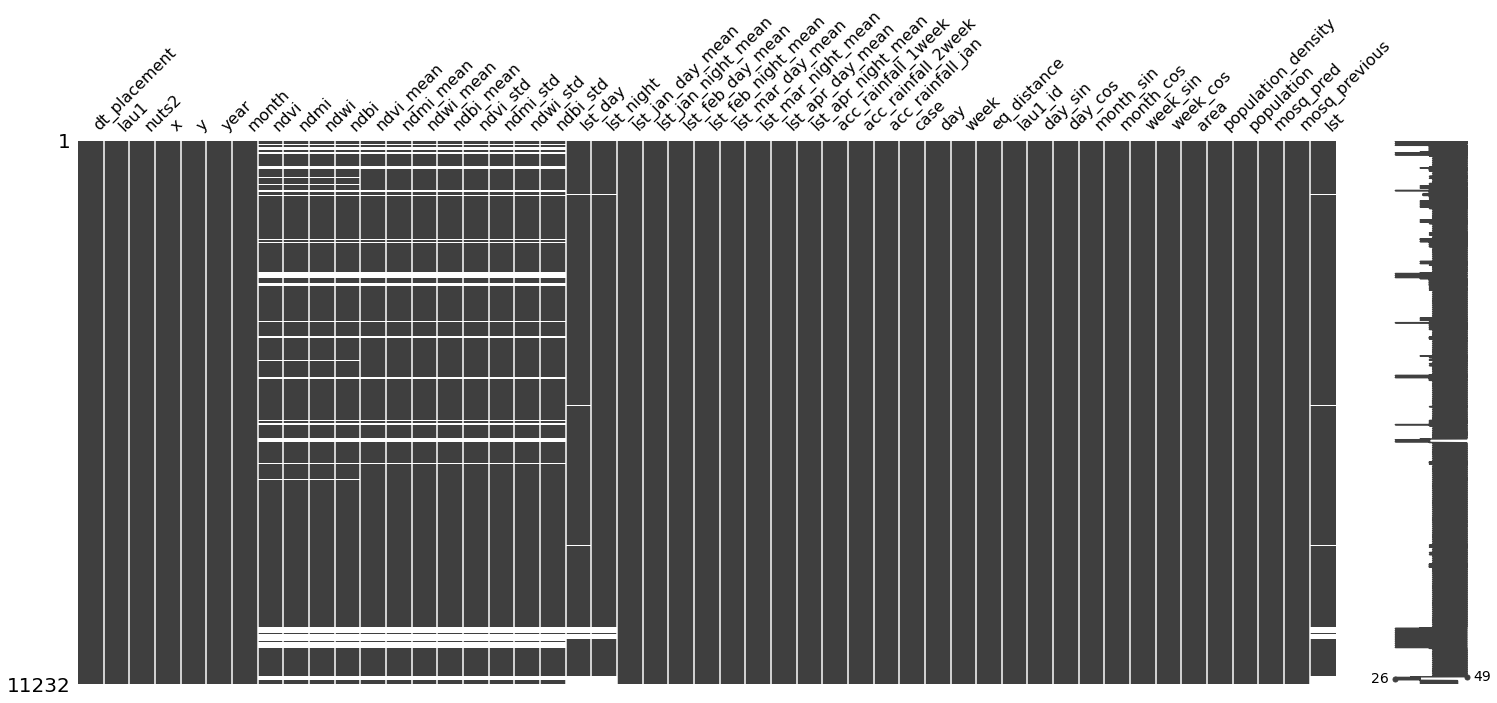

In [81]:
missingno.matrix(dataset)

In [82]:
dataset['case'].value_counts()

0     10896
1       212
2        61
3        23
4        20
      ...  
6         2
11        1
18        1
12        1
9         1
Name: case, Length: 13, dtype: int64

In [83]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [84]:
dataset = convert_multiple_cases(dataset)

In [85]:
dataset['case'].value_counts()

0    10896
1      632
Name: case, dtype: int64

In [86]:
cols = dataset.columns

In [87]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan', 'case',
       'day', 'week', 'eq_distance', 'lau1_id', 'day_sin', 'day_cos',
       'month_sin', 'month_cos', 'week_sin', 'week_cos', 'area',
       'population_density', 'population', 'mosq_pred', 'mosq_previous',
       'lst'],
      dtype='object')

In [88]:
# check columns

In [89]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [90]:
dataset_final = dataset[final_columns].copy()

In [91]:
dataset_final

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,24.12740,40.28807,2010-01-01,κεντρικης μακεδονιας,αθως,28,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,NaN,NaN,NaN,46.96020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.642500,15.530000,9.755000,10.633286,6.832500,8.883182,3.811746,13.083628,6.037902,16.634859,8.565833,34.075000,97.500000,0.575000,1,0,0
1,22.41314,40.63121,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,7,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,478.8,38293.0,86.8,46.40306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.705000,12.360000,7.050000,6.907708,4.406161,10.730556,1.957517,19.149590,4.396618,28.020071,9.308866,14.800000,40.250000,0.000000,1,0,0
2,22.07467,40.99173,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,13,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,985.8,24924.0,28.0,46.55763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.388182,9.579091,5.197273,3.313442,2.001560,3.998298,0.826676,11.100321,2.044771,19.138418,5.884069,20.218182,39.590909,0.045455,1,0,0
3,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,15.000000,39.900000,0.000000,3,0,0
4,23.97067,40.91960,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,35,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,411.8,7169.0,22.3,47.42369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.135000,12.090000,8.180000,8.143000,3.953714,10.209315,2.185636,15.249258,3.555705,20.722821,8.455035,20.225000,29.825000,0.000000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11523,22.32761,40.83927,2018-08-16,κεντρικης μακεδονιας,πελλας,12,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.54426,0.405865,0.142029,-0.351967,-0.142029,0.4684,0.183094,-0.395499,-0.183094,0.080291,0.063893,0.070824,0.063893,25.944000,31.978000,19.910000,10.737173,0.059318,12.899289,1.625429,19.773423,6.003841,26.918608,12.158944,0.260000,4.240000,368.360000,22,99,1
11524,22.32761,40.83927,2018-08-16,κεντρικης μακεδονιας,πελλας,12,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.54426,0.405865,0.142029,-0.351967,-0.142029,0.4684,0.183094,-0.395499,-0.183094,0.080291,0.063893,0.070824,0.063893,25.944000,31.978000,19.910000,10.737173,0.059318,12.899289,1.625429,19.773423,6.003841,26.918608,12.158944,0.260000,4.240000,368.360000,22,99,1
11525,22.32761,40.83927,2018-08-16,κεντρικης μακεδονιας,πελλας,12,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.54426,0.405865,0.142029,-0.351967,-0.142029,0.4684,0.183094,-0.395499,-0.183094,0.080291,0.063893,0.070824,0.063893,25.944000,31.978000,19.910000,10.737173,0.059318,12.899289,1.625429,19.773423,6.003841,26.918608,12.158944,0.260000,4.240000,368.360000,22,99,1
11526,22.32761,40.83927,2018-08-16,κεντρικης μακεδονιας,πελλας,12,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,669.2,56918.0,94.3,46.54426,0.405865,0.142029,-0.351967,-0.142029,0.4684,0.183094,-0.395499,-0.183094,0.080291,0.063893,0.0708

In [92]:
dataset_final.to_csv(f"data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)